In [22]:
import pandas as pd
import numpy as np
from itertools import chain

# Hi-C utilities imports:
import cooler
import bioframe
import cooltools
from cooltools.lib.numutils import fill_diag
from packaging import version
if version.parse(cooltools.__version__) < version.parse('0.5.2'):
    raise AssertionError("tutorials rely on cooltools version 0.5.2 or higher,"+
                         "please check your cooltools version and update to the latest")

# Visualization imports:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.patches as patches
from matplotlib.ticker import EngFormatter

# helper functions for plotting
bp_formatter = EngFormatter('b')
def format_ticks(ax, x=True, y=True, rotate=True):
    """format ticks with genomic coordinates as human readable"""
    if y:
        ax.yaxis.set_major_formatter(bp_formatter)
    if x:
        ax.xaxis.set_major_formatter(bp_formatter)
        ax.xaxis.tick_bottom()
    if rotate:
        ax.tick_params(axis='x',rotation=45)

In [23]:
resolution = 10000
# Load Coolers with the specified resolution dynamically using f-strings
clr_1 = cooler.Cooler(f"/usr/users/papantonis1/aman/microc_data/nadine_macro/RBP1-MNase-R1-filtered.mcool::resolutions/{resolution}")
clr_2 = cooler.Cooler(f"/usr/users/papantonis1/aman/microc_data/nadine_macro/ctrl-MNase-R1-filtered.mcool::resolutions/{resolution}")

In [24]:
# define genomic view that will be used to call dots and pre-compute expected

# Use bioframe to fetch the genomic features from the UCSC.
hg38_chromsizes = bioframe.fetch_chromsizes('hg38')
hg38_cens = bioframe.fetch_centromeres('hg38')
hg38_arms = bioframe.make_chromarms(hg38_chromsizes, hg38_cens)

# Select only chromosomes that are present in the cooler.
hg38_arms = hg38_arms.set_index("chrom").loc[clr_1.chromnames].reset_index()

# intra-arm expected
expected = cooltools.expected_cis(
    clr_1,
    view_df=hg38_arms,
    nproc=4,
)

INFO:root:creating a Pool of 4 workers
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/api/expected.py:351: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = dict(iter(bins.groupby("chrom")[clr_weight_name]))


In [25]:
expected_2 = cooltools.expected_cis(
    clr_2,
    view_df=hg38_arms,
    nproc=4,
)

INFO:root:creating a Pool of 4 workers
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/api/expected.py:351: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = dict(iter(bins.groupby("chrom")[clr_weight_name]))


In [26]:
dots_df_1 = cooltools.dots(
    clr_1,
    expected=expected,
    view_df=hg38_arms,
    # how far from the main diagonal to call dots:
    max_loci_separation=10_000_000,
    nproc=4,
)

INFO:root:Using recommended donut-based kernels with w=5, p=2 for binsize=10000
INFO:root:creating a Pool of 4 workers
INFO:root:convolving 1781 tiles to build histograms for lambda-bins
INFO:root:Done building histograms in 165.752 sec ...
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/api/dotfinder.py:977: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  .idxmin()  # index of the first positive difference
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/api/dotfinder.py:977: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  .idxmin()  # index of the first positive difference
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/api/dotfinder.py:9

In [27]:
dots_df_2 = cooltools.dots(
    clr_2,
    expected=expected_2,
    view_df=hg38_arms,
    # how far from the main diagonal to call dots:
    max_loci_separation=10_000_000,
    nproc=4,
)

INFO:root:Using recommended donut-based kernels with w=5, p=2 for binsize=10000
INFO:root:creating a Pool of 4 workers
INFO:root:convolving 1781 tiles to build histograms for lambda-bins
INFO:root:Done building histograms in 169.554 sec ...
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/api/dotfinder.py:977: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  .idxmin()  # index of the first positive difference
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/api/dotfinder.py:977: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  .idxmin()  # index of the first positive difference
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/api/dotfinder.py:9

In [28]:
# functions
# create a functions that would return a series of rectangles around called dots
# in a specific region, and exposing importnat plotting parameters
def rectangles_around_dots(dots_df, region, loc="upper", lw=1, ec="cyan", fc="none"):
    """
    yield a series of rectangles around called dots in a given region
    """
    # select dots from the region:
    df_reg = bioframe.select(
        bioframe.select(dots_df, region, cols=("chrom1","start1","end1")),
        region,
        cols=("chrom2","start2","end2"),
    )
    rectangle_kwargs = dict(lw=lw, ec=ec, fc=fc)
    # draw rectangular "boxes" around pixels called as dots in the "region":
    for s1, s2, e1, e2 in df_reg[["start1", "start2", "end1", "end2"]].itertuples(index=False):
        width1 = e1 - s1
        width2 = e2 - s2
        if loc == "upper":
            yield patches.Rectangle((s2, s1), width2, width1, **rectangle_kwargs)
        elif loc == "lower":
            yield patches.Rectangle((s1, s2), width1, width2, **rectangle_kwargs)
        else:
            raise ValueError("loc has to be uppper or lower")

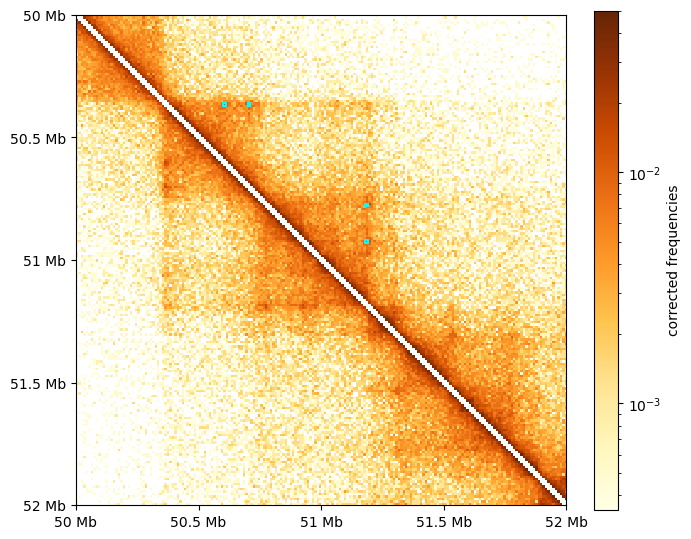

In [29]:
# define a region to look into as an example
chrom = 'chr1'
start = 50_000_000
end = 52_000_000  # 2 Mb window around 50 Mb
region = (chrom, start, end)

# heatmap kwargs
matshow_kwargs = dict(
    cmap='YlOrBr',
    norm=LogNorm(vmax=0.05),
    extent=(start, end, end, start)
)

# colorbar kwargs
colorbar_kwargs = dict(fraction=0.046, label='corrected frequencies')

# compute heatmap for the region
region_matrix = clr_1.matrix(balance=True).fetch(region)
for diag in [-1,0,1]:
    region_matrix = fill_diag(region_matrix, np.nan, i=diag)

# see viz.ipynb for details of heatmap visualization
f, ax = plt.subplots(figsize=(7,7))
im = ax.matshow( region_matrix, **matshow_kwargs)
format_ticks(ax, rotate=False)
plt.colorbar(im, ax=ax, **colorbar_kwargs)

# draw rectangular "boxes" around pixels called as dots in the "region":
for box in rectangles_around_dots(dots_df_1, region, lw=1.5):
    ax.add_patch(box)

plt.savefig("test_output.png")

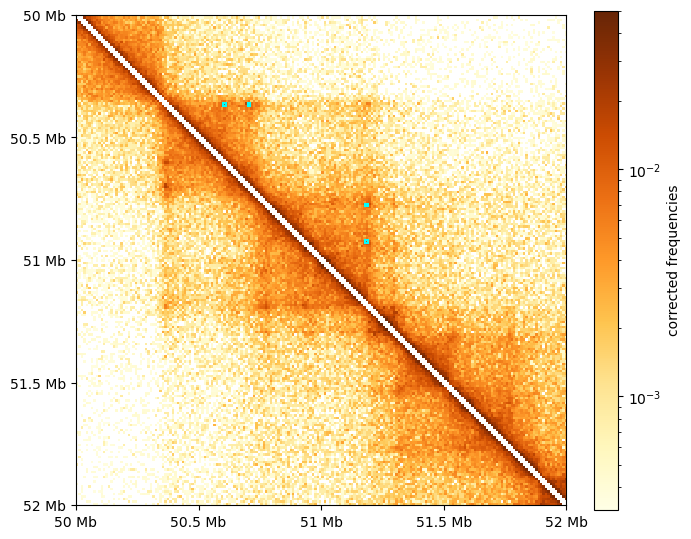

In [30]:
# define a region to look into as an example
chrom = 'chr1'
start = 50_000_000
end = 52_000_000  # 2 Mb window around 50 Mb
region = (chrom, start, end)

# heatmap kwargs
matshow_kwargs = dict(
    cmap='YlOrBr',
    norm=LogNorm(vmax=0.05),
    extent=(start, end, end, start)
)

# colorbar kwargs
colorbar_kwargs = dict(fraction=0.046, label='corrected frequencies')

# compute heatmap for the region
region_matrix = clr_2.matrix(balance=True).fetch(region)
for diag in [-1,0,1]:
    region_matrix = fill_diag(region_matrix, np.nan, i=diag)

# see viz.ipynb for details of heatmap visualization
f, ax = plt.subplots(figsize=(7,7))
im = ax.matshow( region_matrix, **matshow_kwargs)
format_ticks(ax, rotate=False)
plt.colorbar(im, ax=ax, **colorbar_kwargs)

# draw rectangular "boxes" around pixels called as dots in the "region":
for box in rectangles_around_dots(dots_df_1, region, lw=1.5):
    ax.add_patch(box)

plt.savefig("test_output_2.png")

In [31]:
# No clustering
dots_df_all = cooltools.dots(
    clr_1,
    expected=expected,
    view_df=hg38_arms,
    max_loci_separation=10_000_000,
    clustering_radius=None,  # None - implies no clustering
    cluster_filtering=False,  # ignored when clustering is off
    nproc=4,
)

INFO:root:Using recommended donut-based kernels with w=5, p=2 for binsize=10000
INFO:root:creating a Pool of 4 workers
INFO:root:convolving 1781 tiles to build histograms for lambda-bins
INFO:root:Done building histograms in 164.349 sec ...
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/api/dotfinder.py:977: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  .idxmin()  # index of the first positive difference
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/api/dotfinder.py:977: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  .idxmin()  # index of the first positive difference
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/api/dotfinder.py:9

In [32]:
dots_df_all_2 = cooltools.dots(
    clr_2,
    expected=expected_2,
    view_df=hg38_arms,
    max_loci_separation=10_000_000,
    clustering_radius=None,  # None - implies no clustering
    cluster_filtering=False,  # ignored when clustering is off
    nproc=4,
)

INFO:root:Using recommended donut-based kernels with w=5, p=2 for binsize=10000
INFO:root:creating a Pool of 4 workers
INFO:root:convolving 1781 tiles to build histograms for lambda-bins
INFO:root:Done building histograms in 164.066 sec ...
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/api/dotfinder.py:977: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  .idxmin()  # index of the first positive difference
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/api/dotfinder.py:977: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  .idxmin()  # index of the first positive difference
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/api/dotfinder.py:9

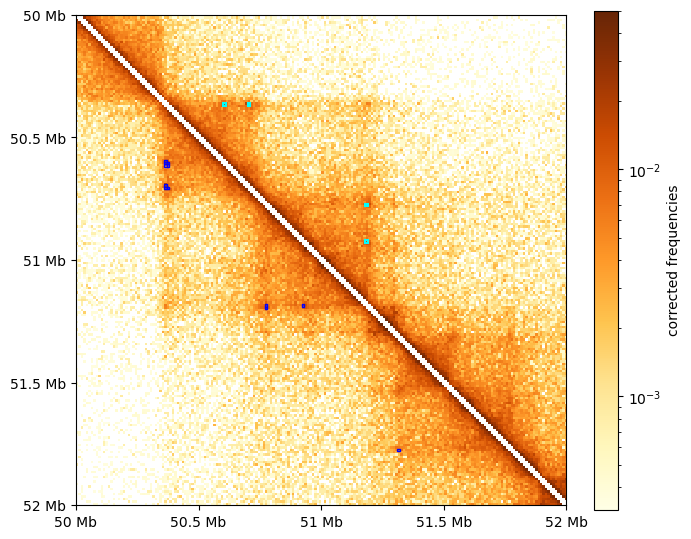

In [33]:
f, ax = plt.subplots(figsize=(7,7))
# draw heatmap
im = ax.matshow(region_matrix, **matshow_kwargs)
format_ticks(ax, rotate=False)
plt.colorbar(im, ax=ax, **colorbar_kwargs)

# draw rectangular "boxes" around pixels called as dots in the "region":
for rect in chain(
        rectangles_around_dots(dots_df_1, region, lw=1.5),  # clustered & filtered
        rectangles_around_dots(dots_df_all, region, loc="lower", ec="blue"),  # unclustered
    ):
    ax.add_patch(rect)

plt.savefig("test_output_3_nocluster1.png")

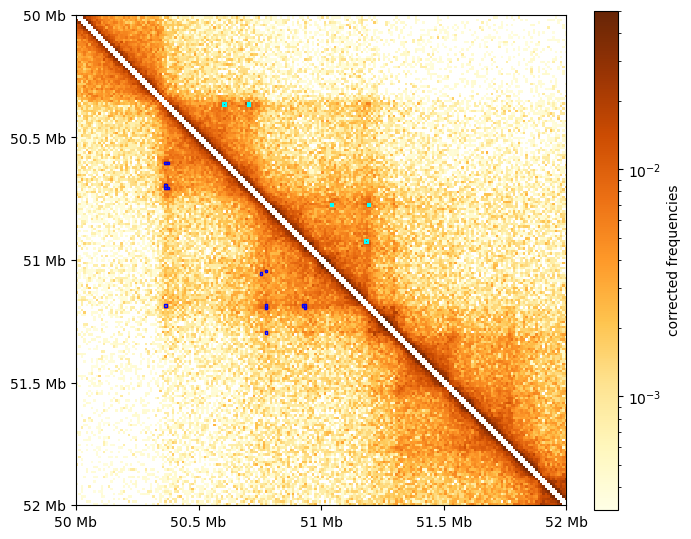

In [34]:
f, ax = plt.subplots(figsize=(7,7))
# draw heatmap
im = ax.matshow(region_matrix, **matshow_kwargs)
format_ticks(ax, rotate=False)
plt.colorbar(im, ax=ax, **colorbar_kwargs)

# draw rectangular "boxes" around pixels called as dots in the "region":
for rect in chain(
        rectangles_around_dots(dots_df_2, region, lw=1.5),  # clustered & filtered
        rectangles_around_dots(dots_df_all_2, region, loc="lower", ec="blue"),  # unclustered
    ):
    ax.add_patch(rect)

plt.savefig("test_output_3_nocluster2.png")

In [35]:
dots_df_1

,chrom1,start1,end1,chrom2,start2,end2,count,la_exp.donut.value,la_exp.vertical.value,la_exp.horizontal.value,...,la_exp.vertical.qval,la_exp.horizontal.qval,la_exp.lowleft.qval,region,cstart1,cstart2,c_label,c_size,region1,region2
0,chr10,2830000,2840000,chr10,3040000,3050000,23,5.532862,6.487207,5.349504,...,2.683761e-03,1.930881e-04,1.931000e-03,chr10_p,2.830000e+06,3.040000e+06,2,1,chr10_p,chr10_p
1,chr10,2920000,2930000,chr10,3040000,3050000,53,11.452140,13.771828,14.278036,...,2.540854e-11,2.567260e-11,8.776740e-15,chr10_p,2.925000e+06,3.045000e+06,3,2,chr10_p,chr10_p
2,chr10,3190000,3200000,chr10,4760000,4770000,35,7.125430,12.089349,7.302278,...,2.357437e-05,2.226186e-09,1.944188e-07,chr10_p,3.205000e+06,4.765000e+06,4,4,chr10_p,chr10_p
3,chr10,3240000,3250000,chr10,4650000,4660000,26,7.298478,8.415197,6.211651,...,2.706376e-03,5.471194e-06,2.986561e-06,chr10_p,3.235000e+06,4.650000e+06,6,2,chr10_p,chr10_p
4,chr10,4840000,4850000,chr10,5090000,5100000,31,8.280750,7.564755,10.593085,...,3.930645e-07,8.170860e-04,1.695211e-05,chr10_p,4.847500e+06,5.090000e+06,9,4,chr10_p,chr10_p
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6786,chrY,10990000,11000000,chrY,11720000,11730000,42,8.339183,5.130682,5.618849,...,7.018122e-17,7.033028e-17,3.792900e-14,chrY_q,1.098000e+07,1.172000e+07,5,2,chrY_q,chrY_q
6787,chrY,11010000,11020000,chrY,11290000,11300000,54,13.302230,14.975148,12.710965,...,7.827029e-12,7.840765e-12,1.337498e-05,chrY_q,1.102000e+07,1.129000e+07,6,2,chrY_q,chrY_q
6788,chrY,11290000,11300000,chrY,11720000,11730000,58,15.720353,8.276865,13.212854,...,8.843112e-22,5.927246e-14,7.015078e-18,chrY_q,1.129667e+07,1.172667e+07,7,3,chrY_q,chrY_q
6789,chrY,11520000,11530000,chrY,11710000,11720000,36,14.980686,11.598452,19.573793,...,8.804204e-06,1.311881e-02,3.297361e-04,chrY_q,1.150500e+07,1.170500e+07,8,2,chrY_q,chrY_q


In [36]:
dots_df_2

,chrom1,start1,end1,chrom2,start2,end2,count,la_exp.donut.value,la_exp.vertical.value,la_exp.horizontal.value,...,la_exp.vertical.qval,la_exp.horizontal.qval,la_exp.lowleft.qval,region,cstart1,cstart2,c_label,c_size,region1,region2
0,chr10,930000,940000,chr10,1050000,1060000,27,10.373481,10.980789,9.899928,...,2.022383e-02,1.299693e-03,1.617047e-02,chr10_p,9.250000e+05,1.055000e+06,1,2,chr10_p,chr10_p
1,chr10,2830000,2840000,chr10,3040000,3050000,25,6.144124,8.439528,6.443026,...,6.919404e-03,4.484180e-04,2.852876e-04,chr10_p,2.830000e+06,3.040000e+06,2,1,chr10_p,chr10_p
2,chr10,2920000,2930000,chr10,3040000,3050000,58,12.624055,17.375465,13.739677,...,2.469186e-10,8.462031e-14,6.599331e-14,chr10_p,2.925000e+06,3.045000e+06,3,2,chr10_p,chr10_p
3,chr10,3190000,3200000,chr10,4760000,4770000,51,9.514215,16.363198,11.195549,...,2.192283e-07,2.232690e-13,1.691436e-13,chr10_p,3.202500e+06,4.760000e+06,6,4,chr10_p,chr10_p
4,chr10,4850000,4860000,chr10,5090000,5100000,56,12.124170,14.697490,13.982871,...,1.006282e-12,9.755243e-13,7.714060e-13,chr10_p,4.846667e+06,5.086667e+06,8,3,chr10_p,chr10_p
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7618,chrY,10990000,11000000,chrY,11720000,11730000,45,7.363204,6.610255,6.293606,...,8.234500e-16,3.386146e-19,3.276725e-16,chrY_q,1.099000e+07,1.172000e+07,6,1,chrY_q,chrY_q
7619,chrY,11010000,11020000,chrY,11290000,11300000,64,17.562373,26.251327,13.153192,...,7.293521e-06,3.491688e-17,2.289190e-09,chrY_q,1.102500e+07,1.129000e+07,7,3,chrY_q,chrY_q
7620,chrY,11300000,11310000,chrY,11720000,11730000,93,35.997487,24.959028,28.719009,...,3.481482e-23,7.073996e-17,3.955952e-11,chrY_q,1.129500e+07,1.172000e+07,8,2,chrY_q,chrY_q
7621,chrY,11520000,11530000,chrY,11710000,11720000,39,14.256546,13.585154,24.164025,...,5.253736e-05,6.967747e-02,1.691606e-03,chrY_q,1.150500e+07,1.170500e+07,9,2,chrY_q,chrY_q


In [37]:
# Select necessary columns for BEDPE
bedpe_df_1 = dots_df_1[['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2']].copy()

# Optional: Add a score or name column if needed
# For example, use 'count' as a score and row index as ID
# bedpe_df_1['name'] = ['loop_' + str(i) for i in range(len(bedpe_df_1))]
# bedpe_df_1['score'] = dots_df['count'].astype(int)  # or any other metric like q-value

# Rearranging columns to standard BEDPE order
# If not using extra columns, just use the first 6
bedpe_bedpe_ordered = bedpe_df_1[['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2']]

# Save to file
bedpe_bedpe_ordered.to_csv("cooltools_RBP1_10kb.bedpe", sep="\t", index=False, header=False)

In [38]:
# Select necessary columns for BEDPE
bedpe_df_2 = dots_df_2[['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2']].copy()

# Optional: Add a score or name column if needed
# For example, use 'count' as a score and row index as ID
# bedpe_df_1['name'] = ['loop_' + str(i) for i in range(len(bedpe_df_1))]
# bedpe_df_1['score'] = dots_df['count'].astype(int)  # or any other metric like q-value

# Rearranging columns to standard BEDPE order
# If not using extra columns, just use the first 6
bedpe_bedpe_ordered = bedpe_df_2[['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2']]

# Save to file
bedpe_bedpe_ordered.to_csv("cooltools_ctrl_10kb.bedpe", sep="\t", index=False, header=False)

In [39]:
significant_loops = dots_df_1[dots_df_1['la_exp.donut.qval'] < 0.01]
significant_loops

,chrom1,start1,end1,chrom2,start2,end2,count,la_exp.donut.value,la_exp.vertical.value,la_exp.horizontal.value,...,la_exp.vertical.qval,la_exp.horizontal.qval,la_exp.lowleft.qval,region,cstart1,cstart2,c_label,c_size,region1,region2
0,chr10,2830000,2840000,chr10,3040000,3050000,23,5.532862,6.487207,5.349504,...,2.683761e-03,1.930881e-04,1.931000e-03,chr10_p,2.830000e+06,3.040000e+06,2,1,chr10_p,chr10_p
1,chr10,2920000,2930000,chr10,3040000,3050000,53,11.452140,13.771828,14.278036,...,2.540854e-11,2.567260e-11,8.776740e-15,chr10_p,2.925000e+06,3.045000e+06,3,2,chr10_p,chr10_p
2,chr10,3190000,3200000,chr10,4760000,4770000,35,7.125430,12.089349,7.302278,...,2.357437e-05,2.226186e-09,1.944188e-07,chr10_p,3.205000e+06,4.765000e+06,4,4,chr10_p,chr10_p
3,chr10,3240000,3250000,chr10,4650000,4660000,26,7.298478,8.415197,6.211651,...,2.706376e-03,5.471194e-06,2.986561e-06,chr10_p,3.235000e+06,4.650000e+06,6,2,chr10_p,chr10_p
4,chr10,4840000,4850000,chr10,5090000,5100000,31,8.280750,7.564755,10.593085,...,3.930645e-07,8.170860e-04,1.695211e-05,chr10_p,4.847500e+06,5.090000e+06,9,4,chr10_p,chr10_p
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6786,chrY,10990000,11000000,chrY,11720000,11730000,42,8.339183,5.130682,5.618849,...,7.018122e-17,7.033028e-17,3.792900e-14,chrY_q,1.098000e+07,1.172000e+07,5,2,chrY_q,chrY_q
6787,chrY,11010000,11020000,chrY,11290000,11300000,54,13.302230,14.975148,12.710965,...,7.827029e-12,7.840765e-12,1.337498e-05,chrY_q,1.102000e+07,1.129000e+07,6,2,chrY_q,chrY_q
6788,chrY,11290000,11300000,chrY,11720000,11730000,58,15.720353,8.276865,13.212854,...,8.843112e-22,5.927246e-14,7.015078e-18,chrY_q,1.129667e+07,1.172667e+07,7,3,chrY_q,chrY_q
6789,chrY,11520000,11530000,chrY,11710000,11720000,36,14.980686,11.598452,19.573793,...,8.804204e-06,1.311881e-02,3.297361e-04,chrY_q,1.150500e+07,1.170500e+07,8,2,chrY_q,chrY_q


In [40]:
significant_loops_2 = dots_df_2[dots_df_2['la_exp.donut.qval'] < 0.01]
significant_loops_2

,chrom1,start1,end1,chrom2,start2,end2,count,la_exp.donut.value,la_exp.vertical.value,la_exp.horizontal.value,...,la_exp.vertical.qval,la_exp.horizontal.qval,la_exp.lowleft.qval,region,cstart1,cstart2,c_label,c_size,region1,region2
1,chr10,2830000,2840000,chr10,3040000,3050000,25,6.144124,8.439528,6.443026,...,6.919404e-03,4.484180e-04,2.852876e-04,chr10_p,2.830000e+06,3.040000e+06,2,1,chr10_p,chr10_p
2,chr10,2920000,2930000,chr10,3040000,3050000,58,12.624055,17.375465,13.739677,...,2.469186e-10,8.462031e-14,6.599331e-14,chr10_p,2.925000e+06,3.045000e+06,3,2,chr10_p,chr10_p
3,chr10,3190000,3200000,chr10,4760000,4770000,51,9.514215,16.363198,11.195549,...,2.192283e-07,2.232690e-13,1.691436e-13,chr10_p,3.202500e+06,4.760000e+06,6,4,chr10_p,chr10_p
4,chr10,4850000,4860000,chr10,5090000,5100000,56,12.124170,14.697490,13.982871,...,1.006282e-12,9.755243e-13,7.714060e-13,chr10_p,4.846667e+06,5.086667e+06,8,3,chr10_p,chr10_p
5,chr10,4850000,4860000,chr10,4980000,4990000,32,11.440849,11.418485,13.458459,...,4.290261e-04,9.798991e-03,7.536522e-03,chr10_p,4.850000e+06,4.980000e+06,9,1,chr10_p,chr10_p
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7618,chrY,10990000,11000000,chrY,11720000,11730000,45,7.363204,6.610255,6.293606,...,8.234500e-16,3.386146e-19,3.276725e-16,chrY_q,1.099000e+07,1.172000e+07,6,1,chrY_q,chrY_q
7619,chrY,11010000,11020000,chrY,11290000,11300000,64,17.562373,26.251327,13.153192,...,7.293521e-06,3.491688e-17,2.289190e-09,chrY_q,1.102500e+07,1.129000e+07,7,3,chrY_q,chrY_q
7620,chrY,11300000,11310000,chrY,11720000,11730000,93,35.997487,24.959028,28.719009,...,3.481482e-23,7.073996e-17,3.955952e-11,chrY_q,1.129500e+07,1.172000e+07,8,2,chrY_q,chrY_q
7621,chrY,11520000,11530000,chrY,11710000,11720000,39,14.256546,13.585154,24.164025,...,5.253736e-05,6.967747e-02,1.691606e-03,chrY_q,1.150500e+07,1.170500e+07,9,2,chrY_q,chrY_q


In [41]:
# Select necessary columns for BEDPE
bedpe_df_1 = significant_loops[['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2']].copy()

# Optional: Add a score or name column if needed
# For example, use 'count' as a score and row index as ID
# bedpe_df_1['name'] = ['loop_' + str(i) for i in range(len(bedpe_df_1))]
# bedpe_df_1['score'] = dots_df['count'].astype(int)  # or any other metric like q-value

# Rearranging columns to standard BEDPE order
# If not using extra columns, just use the first 6
bedpe_bedpe_ordered = bedpe_df_1[['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2']]

# Save to file
bedpe_bedpe_ordered.to_csv("cooltools_RBP1_q001_10kb.bedpe", sep="\t", index=False, header=False)

In [42]:
# Select necessary columns for BEDPE
bedpe_df_2 = significant_loops_2[['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2']].copy()

# Optional: Add a score or name column if needed
# For example, use 'count' as a score and row index as ID
# bedpe_df_1['name'] = ['loop_' + str(i) for i in range(len(bedpe_df_1))]
# bedpe_df_1['score'] = dots_df['count'].astype(int)  # or any other metric like q-value

# Rearranging columns to standard BEDPE order
# If not using extra columns, just use the first 6
bedpe_bedpe_ordered = bedpe_df_2[['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2']]

# Save to file
bedpe_bedpe_ordered.to_csv("cooltools_ctrl_q001_10kb.bedpe", sep="\t", index=False, header=False)